In [9]:
import pandas as pd
from datetime import datetime, date, timedelta, time
import requests

In [ ]:
TOKEN = "72e6575c-9265-45d8-99bb-071bfac38e42"

In [14]:
start_date = pd.Timestamp('2015-02-01 00:00', tz='Europe/Madrid')
end_date = pd.Timestamp('2025-08-31 23:59', tz='Europe/Madrid')

In [15]:
from entsoe import EntsoePandasClient

df = pd.DataFrame()

countries = ['ES']
client = EntsoePandasClient(api_key=TOKEN)
country = 'ES'  # Spain


In [18]:
for country in countries:
    df_country = client.query_load(country_code=country, start=pd.Timestamp(start_date), end=pd.Timestamp(end_date))
    df_country['country'] = country
    df_country.reset_index(names='datetime', inplace=True)
    # df_country['datetime'] = pd.to_datetime(df_country['datetime'])
    # df_country['datetime_utc'] = df_country['datetime'].dt.tz_convert('UTC')
    df = pd.concat([df, df_country], ignore_index=True)
df.rename(columns={'Actual Load': 'load'}, inplace=True)

In [ ]:
ds_pool = client.query_day_ahead_prices(country_code=country, start=pd.Timestamp(start_date), end=pd.Timestamp(end_date))

ValueError: No objects to concatenate

In [ ]:
df_pool = pd.DataFrame(ds_pool, columns=['price'])
df_pool.reset_index(names='datetime', inplace=True)
df_pool['date'] = df_pool['datetime'].dt.date
df_pool_daily = df_pool.groupby(df_pool['datetime'].dt.date)['price'].mean().reset_index()
df_pool_daily.columns = ['date', 'daily_avg_price']
df_pool_merged = pd.merge(df_pool, df_pool_daily, on='date', how='left')

df_pool_merged['price_rate'] = df_pool_merged['price'] / df_pool_merged['daily_avg_price']

ds_price_rate = df_pool_merged.groupby([df_pool_merged['datetime'].dt.year, df_pool_merged['datetime'].dt.month, df_pool_merged['datetime'].dt.hour])['price_rate'].mean()

df_price_target = pd.DataFrame(ds_price_rate, columns=['price_rate'])
df_price_target.index.names = ['year', 'month', 'hour']
df_price_target.reset_index(inplace=True)

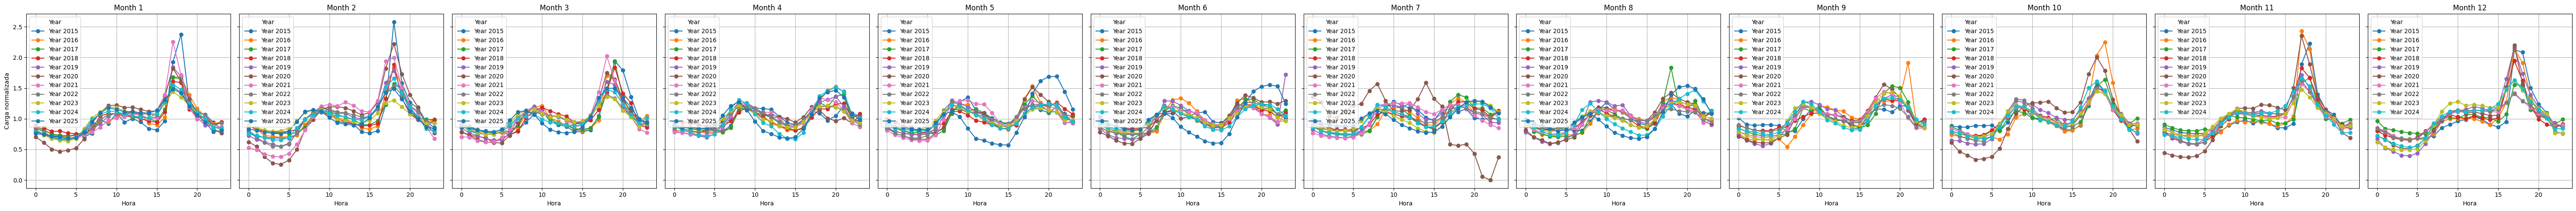

In [ ]:
import matplotlib.pyplot as plt

months = df_price_target['month'].unique()
n_months = len(months)

fig, axes = plt.subplots(1, n_months, figsize=(5 * n_months, 5), sharey=True)

if n_months == 1:
    axes = [axes]  # ensures axes is iterable

for idx, month in enumerate(months):
    ax = axes[idx]
    for year in df_price_target[df_price_target['month'] == month]['year'].unique():
        df_month = df_price_target[(df_price_target['month'] == month) & (df_price_target['year'] == year)]
        ax.plot(df_month['hour'], df_month['price_rate'], marker='o', label=f'Year {year}')
    ax.set_title(f'Month {month}')
    ax.set_xlabel('Hora')
    if idx == 0:
        ax.set_ylabel('Carga normalizada')
    ax.legend(title='Year')
    ax.grid()

plt.tight_layout()
plt.show()